# Experiment: Momentum vs Size Diagnostics

Objective:
- Explain why `Momentum` is insignificant in Task 2.2 pure factor returns while `Size` is highly significant.
- Separate `realized pure factor return` from `next-month predictive IC`.
- Produce report-ready tables and plots for interpretation.

Success criteria:
- Reproduce the main Task 2.2 phenomenon from saved outputs.
- Quantify sign stability for `Size` and sign-flipping for `Momentum`.
- Show whether `Momentum` still has predictive content even if its realized premium mean is near zero.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

ROOT = Path.cwd()
DATA = ROOT / 'data'

for required in [
    DATA / 'sp500_pure_factor_returns.csv.gz',
    DATA / 'sp500_monthly_signals_3factor.csv.gz',
    DATA / 'sp500_monthly_returns.csv.gz',
    DATA / 'F-F_Research_Data_5_Factors_2x3_daily.CSV',
]:
    if not required.exists():
        raise FileNotFoundError(required)


## 1. Load saved outputs

This notebook works from the saved project artifacts rather than re-running the original Phase 2 estimation.
That keeps the diagnosis reproducible and directly tied to the results already reported.


In [2]:
pfr = pd.read_csv(DATA / 'sp500_pure_factor_returns.csv.gz', compression='gzip')
signals = pd.read_csv(DATA / 'sp500_monthly_signals_3factor.csv.gz', compression='gzip')
monthly_returns = pd.read_csv(DATA / 'sp500_monthly_returns.csv.gz', compression='gzip')

pfr['date'] = pd.to_datetime(pfr['date'])
pfr['month_period'] = pd.PeriodIndex(pfr['month'], freq='M')

signals['date'] = pd.to_datetime(signals['date'])
signals['signal_month'] = signals['date'].dt.to_period('M')

monthly_returns['ret_month'] = pd.PeriodIndex(monthly_returns['month'], freq='M')

print(f"Pure factor return sample: {pfr['date'].min().date()} to {pfr['date'].max().date()} ({len(pfr)} months)")
print(f"Signal panel rows: {len(signals):,}")
print(f"Monthly return rows: {len(monthly_returns):,}")


Pure factor return sample: 2010-01-29 to 2024-12-31 (180 months)
Signal panel rows: 115,962
Monthly return rows: 140,070


## 2. Reproduce the pure factor return result

Task 2.2 estimates **realized pure factor returns** from month-by-month cross-sectional regressions.
This is a statement about realized style premia in the same month, not about next-month forecasting power.


In [3]:
factor_specs = [
    ('intercept', 'Intercept (alpha)', 't_intercept'),
    ('f_value', 'Value', 't_value'),
    ('f_size', 'Size', 't_size'),
    ('f_mom', 'Momentum', 't_mom'),
]

summary_rows = []
for ret_col, label, t_col in factor_specs:
    s = pfr[ret_col].dropna()
    t_stat = s.mean() / (s.std(ddof=1) / np.sqrt(len(s)))
    p_value = 2 * stats.t.sf(abs(t_stat), df=len(s) - 1)
    ann_mean = 12 * s.mean()
    ann_vol = np.sqrt(12) * s.std(ddof=1)
    sharpe = ann_mean / ann_vol if ann_vol else np.nan
    summary_rows.append({
        'Factor': label,
        'Mean': s.mean(),
        'Std': s.std(ddof=1),
        't-stat': t_stat,
        'p-value': p_value,
        'Ann.Mean': ann_mean,
        'Sharpe': sharpe,
    })

summary = pd.DataFrame(summary_rows).set_index('Factor')
display(summary)


,Mean,Std,t-stat,p-value,Ann.Mean,Sharpe
Factor,,,,,,
Intercept (alpha),0.0084,0.0488,2.3104,0.0220,0.1008,0.5965
Value,0.0015,0.0085,2.4003,0.0174,0.0183,0.6197
Size,-0.0051,0.0084,-8.1748,0.0000,-0.0613,-2.1107
Momentum,-0.0006,0.0123,-0.6559,0.5128,-0.0072,-0.1693


## 3. Why is `Size` highly significant while `Momentum` is not?

The key diagnostic is **time-series sign stability**:
- a factor can be strong in many individual months but still average to near zero if the sign flips frequently;
- a factor with a stable sign can produce a very large time-series `t-stat` even if individual months are not always dramatic.


,Mean,Ann.Mean,% months > 0,% months < 0,% t > 2,% t < -2,% |t| > 2,Median t-stat
Factor,,,,,,,,
Value,0.0015,0.0183,0.6167,0.3833,0.1222,0.0722,0.1944,0.3640
Size,-0.0051,-0.0613,0.2556,0.7444,0.0500,0.3333,0.3833,-1.1368
Momentum,-0.0006,-0.0072,0.5111,0.4889,0.2556,0.2556,0.5111,0.1969


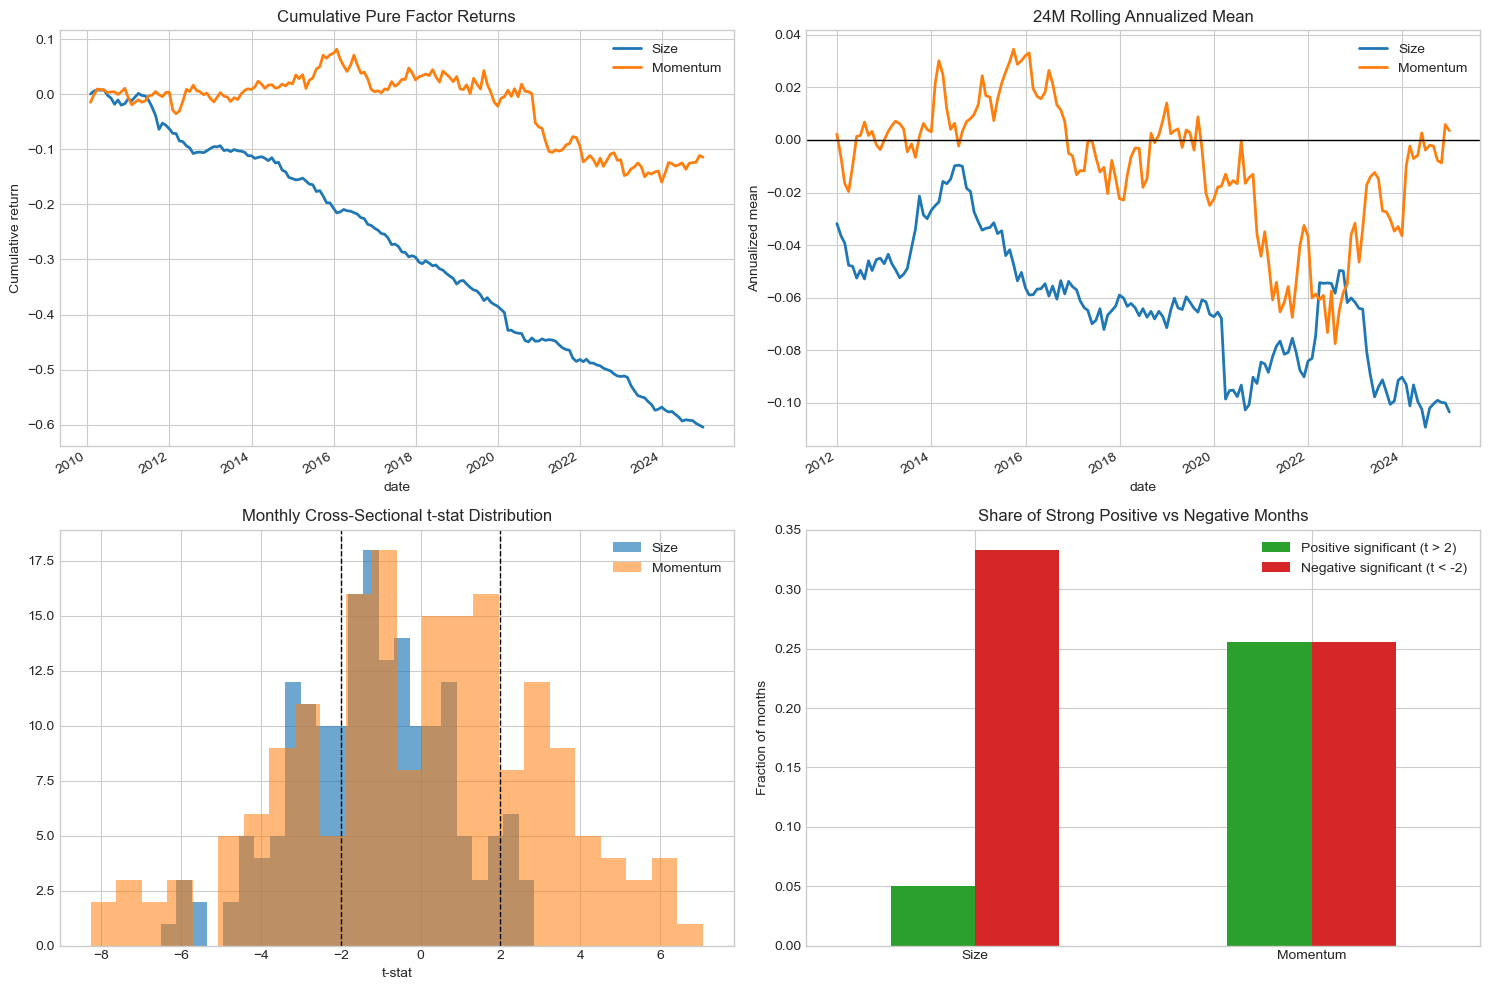

In [4]:
stability_specs = [
    ('f_value', 't_value', 'Value'),
    ('f_size', 't_size', 'Size'),
    ('f_mom', 't_mom', 'Momentum'),
]

stability_rows = []
for ret_col, t_col, label in stability_specs:
    s = pfr[ret_col].dropna()
    t = pfr[t_col].dropna()
    stability_rows.append({
        'Factor': label,
        'Mean': s.mean(),
        'Ann.Mean': 12 * s.mean(),
        '% months > 0': (s > 0).mean(),
        '% months < 0': (s < 0).mean(),
        '% t > 2': (t > 2).mean(),
        '% t < -2': (t < -2).mean(),
        '% |t| > 2': (t.abs() > 2).mean(),
        'Median t-stat': t.median(),
    })

stability = pd.DataFrame(stability_rows).set_index('Factor')
display(stability)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_df = pfr.set_index('date')

cum = (1 + plot_df[['f_size', 'f_mom']]).cumprod() - 1
cum.rename(columns={'f_size': 'Size', 'f_mom': 'Momentum'}).plot(ax=axes[0, 0], linewidth=2)
axes[0, 0].set_title('Cumulative Pure Factor Returns')
axes[0, 0].set_ylabel('Cumulative return')

roll = plot_df[['f_size', 'f_mom']].rolling(24).mean() * 12
roll.rename(columns={'f_size': 'Size', 'f_mom': 'Momentum'}).plot(ax=axes[0, 1], linewidth=2)
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('24M Rolling Annualized Mean')
axes[0, 1].set_ylabel('Annualized mean')

axes[1, 0].hist(plot_df['t_size'], bins=24, alpha=0.65, label='Size', color='#1f77b4')
axes[1, 0].hist(plot_df['t_mom'], bins=24, alpha=0.55, label='Momentum', color='#ff7f0e')
axes[1, 0].axvline(2, color='black', linestyle='--', linewidth=1)
axes[1, 0].axvline(-2, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Monthly Cross-Sectional t-stat Distribution')
axes[1, 0].set_xlabel('t-stat')
axes[1, 0].legend()

sig_bar = pd.DataFrame({
    'Positive significant (t > 2)': [stability.loc['Size', '% t > 2'], stability.loc['Momentum', '% t > 2']],
    'Negative significant (t < -2)': [stability.loc['Size', '% t < -2'], stability.loc['Momentum', '% t < -2']],
}, index=['Size', 'Momentum'])
sig_bar.plot(kind='bar', ax=axes[1, 1], color=['#2ca02c', '#d62728'])
axes[1, 1].set_title('Share of Strong Positive vs Negative Months')
axes[1, 1].set_ylabel('Fraction of months')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 4. Predictive IC is a different question

A factor can have weak average **realized premium** in Task 2.2 but still have useful **next-month cross-sectional forecasting power**.
To check that, we align each month-end factor exposure with the next month's realized return.


In [5]:
forward_returns = monthly_returns[['permno', 'ret_month', 'ret_monthly']].rename(
    columns={'ret_month': 'fwd_month', 'ret_monthly': 'fwd_ret'}
)

ic_panel = signals[['permno', 'signal_month', 'value_factor', 'size_factor', 'momentum_factor']].copy()
ic_panel['fwd_month'] = ic_panel['signal_month'] + 1
ic_panel = ic_panel.merge(forward_returns, on=['permno', 'fwd_month'], how='inner')

raw_factor_map = {
    'value_factor': 'Value',
    'size_factor': 'Size',
    'momentum_factor': 'Momentum',
}

ic_rows = []
for factor_col, label in raw_factor_map.items():
    month_stats = []
    subset = ic_panel[['signal_month', factor_col, 'fwd_ret']].dropna()
    for month, grp in subset.groupby('signal_month'):
        if grp[factor_col].nunique() < 5 or grp['fwd_ret'].nunique() < 5:
            continue
        month_stats.append({
            'month': month,
            'pearson_ic': grp[factor_col].corr(grp['fwd_ret'], method='pearson'),
            'rank_ic': grp[factor_col].corr(grp['fwd_ret'], method='spearman'),
        })
    month_stats = pd.DataFrame(month_stats)
    ic_rows.append({
        'Factor': label,
        'Mean IC': month_stats['pearson_ic'].mean(),
        'Mean Rank IC': month_stats['rank_ic'].mean(),
        '% IC > 0': (month_stats['pearson_ic'] > 0).mean(),
        '% Rank IC > 0': (month_stats['rank_ic'] > 0).mean(),
        'Months': len(month_stats),
    })

ic_summary = pd.DataFrame(ic_rows).set_index('Factor')
display(ic_summary)

comparison = summary[['Mean', 't-stat', 'Ann.Mean']].drop(index='Intercept (alpha)').join(ic_summary)
display(comparison)


,Mean IC,Mean Rank IC,% IC > 0,% Rank IC > 0,Months
Factor,,,,,
Value,0.0167,0.0147,0.6145,0.6369,179
Size,0.0131,0.0081,0.5251,0.5084,179
Momentum,0.0201,0.0156,0.5531,0.5587,179


,Mean,t-stat,Ann.Mean,Mean IC,Mean Rank IC,% IC > 0,% Rank IC > 0,Months
Factor,,,,,,,,
Value,0.0015,2.4003,0.0183,0.0167,0.0147,0.6145,0.6369,179
Size,-0.0051,-8.1748,-0.0613,0.0131,0.0081,0.5251,0.5084,179
Momentum,-0.0006,-0.6559,-0.0072,0.0201,0.0156,0.5531,0.5587,179


## 5. Subperiod check

If a factor is truly persistent, it should keep a similar sign across subperiods.
This check is especially useful for distinguishing stable `Size` effects from more regime-dependent `Momentum` effects.


In [6]:
subperiods = [
    ('2010-2015', '2010-01', '2015-12'),
    ('2016-2020', '2016-01', '2020-12'),
    ('2021-2024', '2021-01', '2024-12'),
]

sub_rows = []
for label, start, end in subperiods:
    mask = (pfr['month_period'] >= pd.Period(start, freq='M')) & (pfr['month_period'] <= pd.Period(end, freq='M'))
    sub = pfr.loc[mask].copy()
    for col, factor_label in [('f_value', 'Value'), ('f_size', 'Size'), ('f_mom', 'Momentum')]:
        s = sub[col].dropna()
        t_like = s.mean() / (s.std(ddof=1) / np.sqrt(len(s)))
        sub_rows.append({
            'Subperiod': label,
            'Factor': factor_label,
            'Ann.Mean': 12 * s.mean(),
            't-like': t_like,
            '% months > 0': (s > 0).mean(),
        })

subperiod_summary = pd.DataFrame(sub_rows)
display(subperiod_summary.pivot(index='Subperiod', columns='Factor', values='Ann.Mean'))
display(subperiod_summary.pivot(index='Subperiod', columns='Factor', values='t-like'))


Factor,Momentum,Size,Value
Subperiod,,,
2010-2015,0.0125,-0.0383,0.0142
2016-2020,-0.0253,-0.0717,0.0029
2021-2024,-0.0141,-0.0827,0.0436


Factor,Momentum,Size,Value
Subperiod,,,
2010-2015,0.9322,-3.8559,1.2975
2016-2020,-1.1356,-5.0425,0.2207
2021-2024,-0.6230,-5.4294,2.6466


## 6. Style cross-check against Fama-French proxies

This is not a formal validation requirement, but it helps interpret whether the project factors behave like familiar styles.
For `Size`, a positive correlation with monthly `SMB` is expected.


In [7]:
ff_daily = pd.read_csv(DATA / 'F-F_Research_Data_5_Factors_2x3_daily.CSV', skiprows=2)
ff_daily = ff_daily.rename(columns={ff_daily.columns[0]: 'date'})
ff_daily['date'] = pd.to_datetime(ff_daily['date'].astype(str), format='%Y%m%d', errors='coerce')
ff_daily = ff_daily.dropna(subset=['date']).copy()

for col in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']:
    ff_daily[col] = pd.to_numeric(ff_daily[col], errors='coerce') / 100.0

ff_daily['month_period'] = ff_daily['date'].dt.to_period('M')
ff_monthly = ff_daily.groupby('month_period')[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']].apply(
    lambda x: (1 + x).prod() - 1
).reset_index()

ff_merged = pfr[['month_period', 'f_value', 'f_size', 'f_mom']].merge(ff_monthly, on='month_period', how='left')
style_corr = pd.DataFrame([
    {'Pair': 'Size vs SMB', 'Correlation': ff_merged['f_size'].corr(ff_merged['SMB'])},
    {'Pair': 'Value vs HML', 'Correlation': ff_merged['f_value'].corr(ff_merged['HML'])},
    {'Pair': 'Momentum vs Mkt-RF', 'Correlation': ff_merged['f_mom'].corr(ff_merged['Mkt-RF'])},
]).set_index('Pair')

display(style_corr)


,Correlation
Pair,
Size vs SMB,0.6433
Value vs HML,-0.0623
Momentum vs Mkt-RF,-0.2776
